# Credit Risk Modeling with Profit Optimization

This project builds a credit scoring model using the German Credit dataset, focusing not only on predictive performance but on **business impact**.

## Objectives
- Predict probability of default
- Optimize decision threshold based on **profit**, not accuracy
- Ensure threshold robustness using cross-validation
- Evaluate fairness across demographic groups
- Simulate real-world business scenarios

## Project Structure

The modeling pipeline follows a production-like workflow:

1. Data loading and preprocessing
2. Baseline modeling
3. Advanced modeling (XGBoost)
4. Probability calibration
5. Business-driven threshold optimization
6. Robustness validation (cross-validation)
7. Business simulation and stress testing
8. Explainability and fairness analysis

## Key Features
- Logistic Regression baseline
- XGBoost with hyperparameter tuning
- Probability calibration
- Profit-driven threshold optimization
- Stress testing and scenario analysis
- SHAP explainability
- Fairness evaluation and mitigation

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import clone

from xgboost import XGBClassifier

import shap
import joblib

c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading and Preparation

We load the German Credit dataset and define the target variable:

- `0` → Good credit (no default)
- `1` → Bad credit (default)

In [2]:
sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data

df = load_data("../data/raw/german.data").copy()

In [3]:
df['target'] = df['target'].map({1: 0, 2: 1})
df['target'].value_counts(normalize=True)

target
0    0.7
1    0.3
Name: proportion, dtype: float64

In [4]:
X = df.drop(columns=['target'])
y = df['target']

## Feature Engineering

We separate features into:
- Numerical variables → scaled
- Categorical variables → one-hot encoded

In [5]:
numerical_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

print(numerical_cols)
print(categorical_cols)

['duration', 'credit_amount', 'installment_rate', 'present_residence', 'age', 'number_of_credits', 'people_liable']
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [6]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Train-Test Split

We use a stratified split to preserve the class distribution.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Baseline Model: Logistic Regression

A simple baseline model is trained to establish initial performance.
Class imbalance is handled using `class_weight='balanced'`.

In [9]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [10]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
y_pred = logistic_pipeline.predict(X_test)
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

### Baseline Performance

We evaluate the model using:
- Accuracy
- Precision
- Recall
- AUC

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n--- END BASELINE ---\n")

Accuracy: 0.75
Precision: 0.5581395348837209
Recall: 0.8
AUC: 0.8058333333333333
Confusion Matrix:
 [[102  38]
 [ 12  48]]

--- END BASELINE ---



## Why Accuracy is Not Enough

Traditional metrics like accuracy or AUC do not capture real business impact.

In credit risk:
- Approving a bad client (default) is very costly
- Rejecting a good client is a lost opportunity

Therefore, we shift from **model-centric metrics** to **business-centric optimization**.

## Business Objective: Profit Optimization

Instead of optimizing accuracy, we define a business-driven objective:

- Profit from approving good clients
- Cost of approving bad clients (default)
- Cost of rejecting good clients

This allows us to align the model with real-world financial impact.

In [13]:
PROFIT_TP = 15000   
COST_FN = 10000
COST_FP = 5000

def business_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    gain_tp = tp * PROFIT_TP
    
    loss_fn = fn * COST_FN   
    loss_fp = fp * COST_FP   
    
    profit = gain_tp - loss_fn - loss_fp
    
    return profit


## Profit vs Threshold

We evaluate how decision thresholds impact total profit.

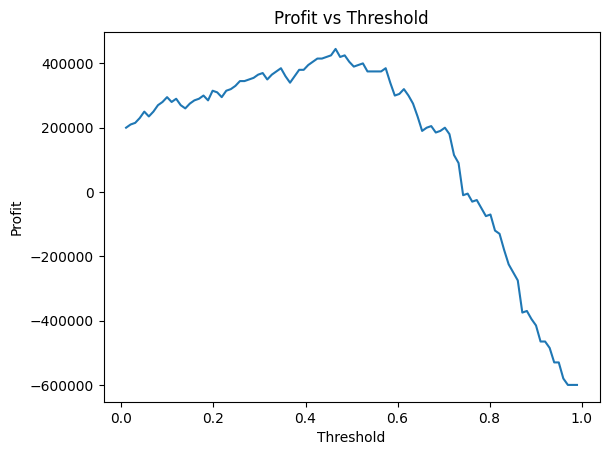

In [14]:
ts = np.linspace(0.01, 0.99, 100)
profits_plot = []

for t in ts:
    y_pred = (y_proba >= t).astype(int)
    profits_plot.append(business_profit(y_test, y_pred))

plt.plot(ts, profits_plot)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.show()

In [15]:
t = 0.35
y_pred_final = (y_proba >= t).astype(int)

In [16]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))

Confusion Matrix:
 [[77 63]
 [ 9 51]]
Precision: 0.4473684210526316
Recall: 0.85


## Advanced Model: XGBoost

We train a gradient boosting model with hyperparameter tuning to improve predictive performance.

In [17]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.05, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best AUC:", grid.best_score_)

best_model = grid.best_estimator_

c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 100}
Best AUC: 0.7924107142857142


## Probability Calibration

We calibrate predicted probabilities using isotonic regression to ensure they reflect true default likelihood.

In [18]:
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='isotonic',
    cv=5
)

calibrated_model.fit(X_train, y_train)

y_proba = calibrated_model.predict_proba(X_test)[:, 1]



c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:7

## Threshold Optimization

We select the decision threshold that maximizes business profit.

### Warning: Data Leakage

Optimizing the threshold on the test set leads to overly optimistic results.

We use it only for reference, not for final decision-making.

In [19]:
def optimize_threshold(y_true, y_proba, profit_fn):
    best_t = 0
    best_profit = -float('inf')
    
    for t in np.linspace(0.01, 0.99, 100):
        y_pred = (y_proba >= t).astype(int)
        profit = profit_fn(y_true, y_pred)
        
        if profit > best_profit:
            best_profit = profit
            best_t = t
    
    return best_t, best_profit


test_optimal_t, test_profit = optimize_threshold(
    y_test,
    y_proba,
    business_profit
)

print("Test-optimal threshold (DO NOT USE):", test_optimal_t)

Test-optimal threshold (DO NOT USE): 0.24757575757575756


## Threshold Stability (Cross-Validation)

We evaluate how stable the optimal threshold is across different data splits.
A stable threshold indicates robustness.

## Why Threshold Stability Matters

A threshold optimized on a single dataset split may not generalize.

We evaluate stability using cross-validation to ensure:
- Consistent decision-making
- Reduced overfitting to a specific sample
- Reliable deployment behavior

In [20]:
def threshold_stability(X, y, model, profit_fn):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    thresholds = []
    
    for train_idx, val_idx in skf.split(X, y):
        model_clone = clone(model)
        
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model_clone.fit(X_tr, y_tr)
        
        y_proba_val = model_clone.predict_proba(X_val)[:, 1]
        
        t, _ = optimize_threshold(y_val, y_proba_val, profit_fn)
        thresholds.append(t)
    
    return thresholds


thresholds_cv = threshold_stability(
    X,
    y,
    calibrated_model,
    business_profit
)

print("\nThreshold Stability (CV):", thresholds_cv)
print("Mean threshold:", np.mean(thresholds_cv))
print("Std:", np.std(thresholds_cv))

c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\danie\credit_scoring_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:7


Threshold Stability (CV): [np.float64(0.18818181818181817), np.float64(0.07929292929292929), np.float64(0.12878787878787878), np.float64(0.1782828282828283), np.float64(0.15848484848484848)]
Mean threshold: 0.1466060606060606
Std: 0.03929786783121944


## Final Threshold Selection

We use the **median threshold across folds** to ensure robustness.

In [21]:
robust_threshold = np.median(thresholds_cv)

print("\nRobust threshold (CV median):", robust_threshold)

print("\n--- THRESHOLD VALIDATION ---")

if np.std(thresholds_cv) < 0.05:
    print("Threshold is stable across folds")
else:
    print("Threshold is not stable, consider more data or regularization")

# FINAL SELECTION

FINAL_THRESHOLD = robust_threshold

print("\nFinal threshold selected:", FINAL_THRESHOLD)

print("\n--- FINAL MODEL READY ---\n")


Robust threshold (CV median): 0.15848484848484848

--- THRESHOLD VALIDATION ---
Threshold is stable across folds

Final threshold selected: 0.15848484848484848

--- FINAL MODEL READY ---



## Legacy Approach (Cost-Based Optimization)

For comparison, we include a traditional cost-minimization approach.

This highlights why profit-based optimization is more aligned with business goals.

In [22]:
LEGACY_COST_FN = 10000
LEGACY_COST_FP = 1000

def business_cost(y_true, y_pred, cost_fn, cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fn * cost_fn) + (fp * cost_fp)

thresholds = np.linspace(0.1, 0.9, 50)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cost = business_cost(y_test, y_pred_t, LEGACY_COST_FN, LEGACY_COST_FP)
    results.append((t, cost))

best_threshold, min_cost = min(results, key=lambda x: x[1])

print("Best threshold:", best_threshold)
print("Minimum business cost:", min_cost)

THRESHOLD = best_threshold
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))

Best threshold: 0.1
Minimum business cost: 114000
Confusion Matrix:
 [[ 36 104]
 [  1  59]]
Precision: 0.3619631901840491
Recall: 0.9833333333333333


## Cost Sensitivity Analysis

We analyze how different cost ratios between false negatives and false positives affect the optimal threshold.

This helps understand how business priorities impact model decisions.

In [23]:
cost_ratios = [2, 5, 10, 20]

for ratio in cost_ratios:
    cost_fn = 10000
    cost_fp = cost_fn / ratio
    
    results = []
    
    for t in np.linspace(0.1, 0.9, 50):
        y_pred_t = (y_proba >= t).astype(int)
        cost = business_cost(y_test, y_pred_t, cost_fn, cost_fp)
        results.append((t, cost))
    
    best_t, min_c = min(results, key=lambda x: x[1])
    
    print(f"\nRatio FN/FP = {ratio}")
    print(f"Best threshold: {best_t:.3f}")
    print(f"Min cost: {min_c}")


Ratio FN/FP = 2
Best threshold: 0.312
Min cost: 340000.0

Ratio FN/FP = 5
Best threshold: 0.247
Min cost: 208000.0

Ratio FN/FP = 10
Best threshold: 0.100
Min cost: 114000.0

Ratio FN/FP = 20
Best threshold: 0.100
Min cost: 62000.0


## Threshold Comparison

We compare different threshold strategies to understand trade-offs between risk and approval rates.

In [24]:
t1 = best_threshold
t2 = 0.35

for t in [t1, t2]:
    y_pred_t = (y_proba >= t).astype(int)
    
    print(f"\nThreshold: {t:.3f}")
    print(confusion_matrix(y_test, y_pred_t))


Threshold: 0.100
[[ 36 104]
 [  1  59]]

Threshold: 0.350
[[103  37]
 [ 17  43]]


## Profit Curve (Final Model)

We re-evaluate the profit curve using the calibrated model to confirm the optimal threshold behavior.

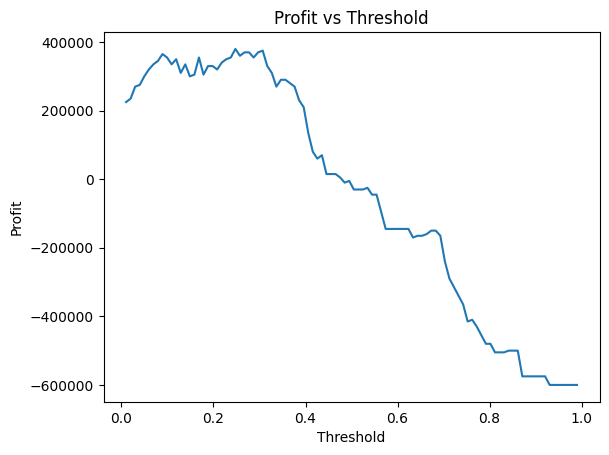

In [25]:
profits = []

ts = np.linspace(0.01, 0.99, 100)

for t in ts:
    y_pred = (y_proba >= t).astype(int)
    profits.append(business_profit(y_test, y_pred))

plt.plot(ts, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.show()

## Portfolio Simulation

We simulate how the model performs in a real lending scenario:
- Approval rate
- Default rate
- Expected profit

In [26]:
def portfolio_simulation(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    approval_rate = y_pred.mean()
    default_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    expected_loss = fn * COST_FN + fp * COST_FP
    
    return {
        "approval_rate": approval_rate,
        "default_rate": default_rate,
        "profit": business_profit(y_true, y_pred),
        "expected_loss": expected_loss,
        "confusion_matrix": (tn, fp, fn, tp)
    }


sim = portfolio_simulation(y_test, y_proba, FINAL_THRESHOLD)

print("\nPORTFOLIO SIMULATION:")
for k, v in sim.items():
    print(f"{k}: {v}")


PORTFOLIO SIMULATION:
approval_rate: 0.685
default_rate: 0.11666666666666667
profit: 305000
expected_loss: 490000
confusion_matrix: (np.int64(56), np.int64(84), np.int64(7), np.int64(53))


In [27]:
print("\nINTERPRETATION:")
print(f"Out of every 100 applicants, {sim['approval_rate']*100:.1f} are approved")
print(f"Among approved clients, {sim['default_rate']*100:.1f}% default")


INTERPRETATION:
Out of every 100 applicants, 68.5 are approved
Among approved clients, 11.7% default


## Stress Testing

We evaluate model performance under adverse scenarios where default costs increase.

In [28]:
def stress_test(y_true, y_proba, threshold, default_multiplier=1.0):
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    stressed_fn = fn * default_multiplier
    
    profit = (
        tp * PROFIT_TP
        - stressed_fn * COST_FN
        - fp * COST_FP
    )
    
    return profit

scenarios_stress = {
    "Normal": 1.0,
    "Mild Crisis": 1.5,
    "Severe Crisis": 2.0
}

print("\n--- STRESS TEST ---")

for name, multiplier in scenarios_stress.items():
    p = stress_test(y_test, y_proba, FINAL_THRESHOLD, multiplier)
    print(f"{name}: profit = {p}")


--- STRESS TEST ---
Normal: profit = 305000.0
Mild Crisis: profit = 270000.0
Severe Crisis: profit = 235000.0


## Business Scenario Analysis

We analyze how different business strategies affect optimal thresholds:
- Conservative
- Balanced
- Growth-oriented

In [29]:
scenarios = [
    {"name": "Conservative", "PROFIT_TP": 5000, "COST_FN": 10000, "COST_FP": 8000},
    {"name": "Balanced", "PROFIT_TP": 10000, "COST_FN": 10000, "COST_FP": 7000},
    {"name": "Growth", "PROFIT_TP": 15000, "COST_FN": 10000, "COST_FP": 5000},
]

for s in scenarios:
    results = []
    
    for t in np.linspace(0.1, 0.9, 50):
        y_pred_t = (y_proba >= t).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        
        profit = (
            tp * s["PROFIT_TP"]
            - fn * s["COST_FN"]
            - fp * s["COST_FP"]
        )
        
        results.append((t, profit))
    
    best_t, max_p = max(results, key=lambda x: x[1])
    
    print(f"\nScenario: {s['name']}")
    print(f"Best threshold: {best_t:.3f}")
    print(f"Max profit: {max_p}")


Scenario: Conservative
Best threshold: 0.312
Max profit: -232000

Scenario: Balanced
Best threshold: 0.312
Max profit: 52000

Scenario: Growth
Best threshold: 0.247
Max profit: 380000


In [48]:
## Scenario Analysis (Production-Ready)

print("\n--- SCENARIO ANALYSIS (FIXED THRESHOLD) ---")

for s in scenarios:
    
    y_pred = (y_proba >= FINAL_THRESHOLD).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    profit = (
        tp * s["PROFIT_TP"]
        - fn * s["COST_FN"]
        - fp * s["COST_FP"]
    )
    
    approval_rate = y_pred.mean()
    default_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print(f"\nScenario: {s['name']}")
    print(f"Threshold used: {FINAL_THRESHOLD:.3f}")
    print(f"Profit: {profit}")
    print(f"Approval rate: {approval_rate:.2%}")
    print(f"Default rate: {default_rate:.2%}")


--- SCENARIO ANALYSIS (FIXED THRESHOLD) ---

Scenario: Conservative
Threshold used: 0.158
Profit: -477000
Approval rate: 68.50%
Default rate: 11.67%

Scenario: Balanced
Threshold used: 0.158
Profit: -128000
Approval rate: 68.50%
Default rate: 11.67%

Scenario: Growth
Threshold used: 0.158
Profit: 305000
Approval rate: 68.50%
Default rate: 11.67%


## Interpretation

The model remains stable across scenarios, maintaining consistent approval (~68.5%) and default (~11.7%) rates.

However, profitability varies significantly depending on business assumptions:

- Conservative scenario results in negative profit due to high penalties on misclassification.
- Balanced scenario is close to breakeven but still unprofitable.
- Growth scenario generates strong positive returns under more favorable economics.

### Key Insight

The model does not guarantee profitability — it enables decision-making.

Profitability depends on how the business values risk (cost of default vs. reward of good clients), not only on predictive performance.

### Business Implication

A single model can support multiple strategies:

- Risk-averse environments may require stricter thresholds or different pricing strategies.
- Growth-oriented environments can leverage the same model to maximize returns.

This highlights that **machine learning models must be aligned with business strategy**, not evaluated in isolation.

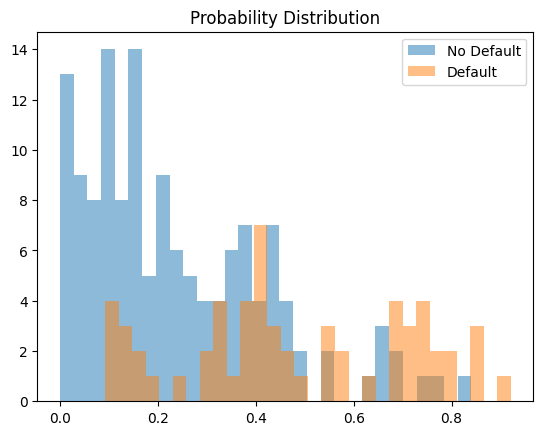

In [30]:
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.5, label="No Default")
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.5, label="Default")
plt.legend()
plt.title("Probability Distribution")
plt.show()

## Model Comparison

We compare Logistic Regression vs XGBoost using AUC.

In [31]:
print("AUC XGBoost:", roc_auc_score(y_test, y_proba))
baseline_auc = roc_auc_score(y_test, logistic_pipeline.predict_proba(X_test)[:,1])

print("\n--- MODEL COMPARISON ---")
print(f"Baseline (Logistic): {baseline_auc:.3f}")
print(f"XGBoost: {roc_auc_score(y_test, y_proba):.3f}")

AUC XGBoost: 0.7932142857142858

--- MODEL COMPARISON ---
Baseline (Logistic): 0.806
XGBoost: 0.793


## Calibration Analysis

We verify that predicted probabilities match observed outcomes.

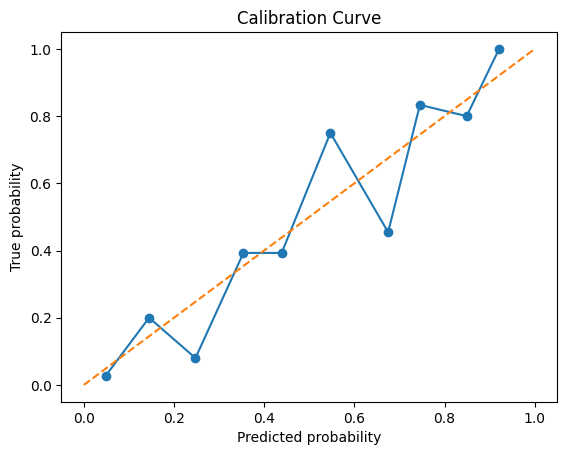

In [32]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.show()

## Model Explainability (SHAP)

We analyze feature importance using SHAP values to understand model behavior.

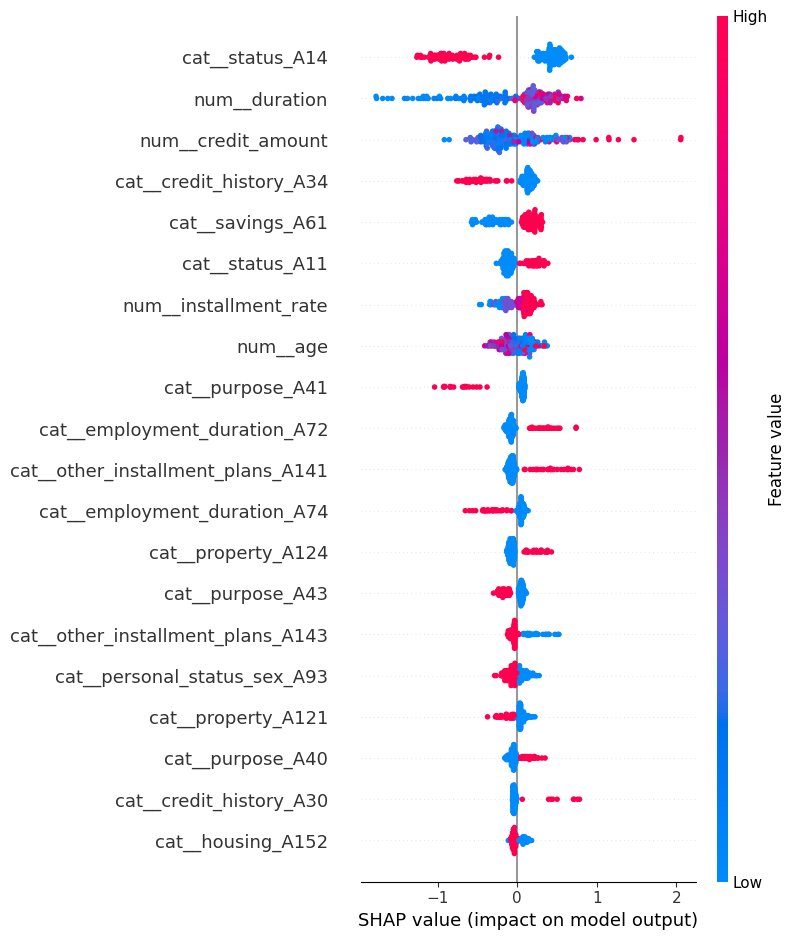

In [33]:
base_model = best_model.named_steps['model']

X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(base_model)

shap_values = explainer.shap_values(X_test_transformed)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

shap.summary_plot(shap_values, X_test_df)

## Fairness Analysis

We evaluate model performance across demographic groups.

## Ethical Considerations

Credit models can introduce unintended bias across demographic groups.

We evaluate fairness to ensure:
- Equitable approval rates
- Consistent true positive rates
- Awareness of trade-offs between fairness and profit

In [34]:
df_test = X_test.copy()
df_test['target'] = y_test.values
df_test['y_pred'] = (y_proba >= FINAL_THRESHOLD).astype(int)
df_test['y_proba'] = y_proba

In [35]:
df_test['age_group'] = df_test['age'].apply(lambda x: 'young' if x < 30 else 'adult')

We derive a proxy gender variable based on encoded categorical values.

Note: This is a simplification and may not reflect real-world demographic definitions.

In [36]:
df_test['is_male'] = df_test['personal_status_sex'].apply(
    lambda x: 1 if x in ['A91', 'A93', 'A94'] else 0
)

In [37]:
df_test.groupby('age_group')['y_pred'].mean()
print("\n--- FAIRNESS METRICS ---")

for group in ['young', 'adult']:
    subset = df_test[df_test['age_group'] == group]
    
    tn, fp, fn, tp = confusion_matrix(
        subset['target'],
        subset['y_pred']
    ).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"{group} TPR: {tpr:.3f}")


--- FAIRNESS METRICS ---
young TPR: 0.882
adult TPR: 0.885


## Fairness Mitigation

We apply group-specific thresholds to reduce disparities.

In [38]:
def apply_group_threshold(df, threshold_young, threshold_adult):
    preds = []
    
    for _, row in df.iterrows():
        if row['age_group'] == 'young':
            preds.append(int(row['y_proba'] >= threshold_young))
        else:
            preds.append(int(row['y_proba'] >= threshold_adult))
    
    return preds

df_test['y_pred_fair'] = apply_group_threshold(df_test, 0.4, 0.3)

print("Before mitigation:")
print(df_test.groupby('age_group')['y_pred'].mean())

print("\nAfter mitigation:")
print(df_test.groupby('age_group')['y_pred_fair'].mean())

Before mitigation:
age_group
adult    0.628099
young    0.772152
Name: y_pred, dtype: float64

After mitigation:
age_group
adult    0.396694
young    0.443038
Name: y_pred_fair, dtype: float64


## Fairness vs Profit Trade-off

We evaluate how fairness interventions impact business performance.

This highlights the trade-off between ethical considerations and profitability.

In [39]:
def portfolio_simulation_from_preds(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    approval_rate = y_pred.mean()
    default_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    profit = (
        tp * PROFIT_TP
        - fn * COST_FN
        - fp * COST_FP
    )
    
    return {
        "approval_rate": approval_rate,
        "default_rate": default_rate,
        "profit": profit,
        "confusion_matrix": (tn, fp, fn, tp)
    }

sim_original = portfolio_simulation(y_test, y_proba, FINAL_THRESHOLD)

sim_fair = portfolio_simulation_from_preds(
    y_test,
    df_test['y_pred_fair']
)

print("\n--- ORIGINAL MODEL ---")
for k, v in sim_original.items():
    print(f"{k}: {v}")

print("\n--- FAIR MODEL ---")
for k, v in sim_fair.items():
    print(f"{k}: {v}")


--- ORIGINAL MODEL ---
approval_rate: 0.685
default_rate: 0.11666666666666667
profit: 305000
expected_loss: 490000
confusion_matrix: (np.int64(56), np.int64(84), np.int64(7), np.int64(53))

--- FAIR MODEL ---
approval_rate: 0.415
default_rate: 0.25
profit: 335000
confusion_matrix: (np.int64(102), np.int64(38), np.int64(15), np.int64(45))


In [40]:
df_test.groupby('is_male')['y_pred'].mean()

is_male
0    0.737705
1    0.661871
Name: y_pred, dtype: float64

In [41]:
df_test[df_test['target'] == 1].groupby('age_group')['y_pred'].mean()

age_group
adult    0.884615
young    0.882353
Name: y_pred, dtype: float64

In [42]:
df_test[df_test['target'] == 1].groupby('is_male')['y_pred'].mean()

is_male
0    0.900
1    0.875
Name: y_pred, dtype: float64

## Final Business Decision

This section simulates how a real credit policy would be defined.

We select the final threshold based on:
- Profit
- Risk control
- Stability

In [43]:
print("\n--- FINAL DECISION ---")

final_profit = business_profit(y_test, (y_proba >= FINAL_THRESHOLD).astype(int))

print(f"""
Recommended threshold: {FINAL_THRESHOLD:.3f}

Rationale:
- Expected profit: {final_profit}
- Approval rate: {sim['approval_rate']*100:.1f}%
- Default rate: {sim['default_rate']*100:.1f}%

Business Interpretation:
This threshold balances growth and risk, avoiding excessive rejection 
of good clients while maintaining a controlled default rate.
""")


--- FINAL DECISION ---

Recommended threshold: 0.158

Rationale:
- Expected profit: 305000
- Approval rate: 68.5%
- Default rate: 11.7%

Business Interpretation:
This threshold balances growth and risk, avoiding excessive rejection 
of good clients while maintaining a controlled default rate.



In [44]:
FINAL_THRESHOLD = robust_threshold

joblib.dump(FINAL_THRESHOLD, "../models/threshold.pkl")

['../models/threshold.pkl']

In [45]:
joblib.dump(calibrated_model, "../models/model.pkl")

['../models/model.pkl']

In [46]:
joblib.dump(best_model.named_steps['preprocessor'], "../models/preprocessor.pkl")

['../models/preprocessor.pkl']

In [47]:
# use a sample from training data
background = best_model.named_steps['preprocessor'].transform(X_train.sample(100, random_state=42))

joblib.dump(background, "../models/background.pkl")

['../models/background.pkl']